# Homework 4

# Part A

Prompt: 

I am working on Homework 4 for ISyE 4803 Financial Data Analysis. I have two files: m_sp500ret_3mtcm.txt with monthly S&P 500 returns and 3-month T-bill rates, and m_logret_10stocks.txt with monthly log returns for 10 stocks. Please write R code to fit the CAPM model for each stock and also python code to compare the results:

stock excess return = alpha + beta * market excess return + error

Use rf_monthly = X3mTCM / 100 / 12 and market_excess = sp500 - rf_monthly. For each stock, report alpha, beta, alpha p-value, and whether CAPM holds based on testing alpha = 0 at the 5% significance level.

In [1]:
# HW4 CAPM — Part A claude code in python than R
# Read data
# skiprows=1 skips the first comment line in the market file
market = pd.read_csv("m_sp500ret_3mtcm.txt", sep=r"\s+", skiprows=1)
stocks = pd.read_csv("m_logret_10stocks.txt", sep=r"\s+")
 
# Create monthly risk-free rate
market["rf_monthly"] = market["3mTCM"] / 100 / 12

# Create market excess return
market["market_excess"] = market["sp500"] - market["rf_monthly"]

# Stock names, excluding Date column
stock_names = stocks.columns[1:]

# Empty list to store results
results = []

# Fit CAPM for each stock
for stock in stock_names:
    
    # Create stock excess return
    stock_excess = stocks[stock] - market["rf_monthly"]
    
    # X = market excess return with intercept
    X = sm.add_constant(market["market_excess"])
    
    # y = stock excess return
    y = stock_excess
    
    # Fit CAPM regression
    model = sm.OLS(y, X).fit()
    
    # Alpha is intercept
    alpha = model.params["const"]
    alpha_p = model.pvalues["const"]
    
    # Beta is slope
    beta = model.params["market_excess"]
    
    # CAPM holds if alpha is not statistically significant
    capm_result = "Holds" if alpha_p > 0.05 else "Rejected"
    
    # Store results
    results.append({
        "Stock": stock,
        "Alpha": alpha,
        "Beta": beta,
        "Alpha_p_value": alpha_p,
        "CAPM_holds": capm_result
    })

# Convert results to DataFrame
results_df = pd.DataFrame(results)

# Print results
results_df

,Stock,Alpha,Beta,Alpha_p_value,CAPM_holds
0,AAPL,0.003847,1.384640,0.447607,Holds
1,ADBE,0.004658,1.531350,0.342159,Holds
2,ADP,0.000807,0.847677,0.668582,Holds
3,AMD,-0.000619,2.323827,0.916825,Holds
4,DELL,0.008884,1.674992,0.032032,Rejected
5,GTW,-0.005425,2.232802,0.336194,Holds
6,HP,0.001900,0.875234,0.602904,Holds
7,IBM,0.002626,1.347923,0.275263,Holds
8,MSFT,0.004256,1.458539,0.148168,Holds
9,ORCL,0.003910,1.567604,0.379769,Holds


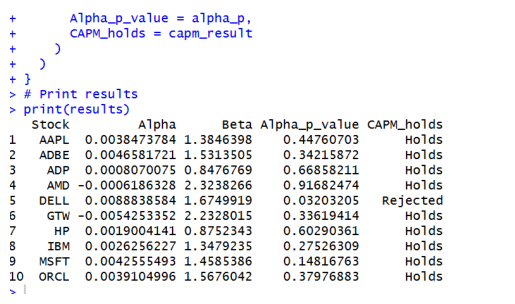

In [2]:
from PIL import Image
import matplotlib.pyplot as plt

img = Image.open(r"C:\Users\gorgi\Downloads\seoul4803\pic4.png")

plt.imshow(img)
plt.axis("off")
plt.show()

# Part B

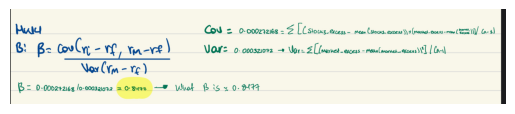

In [10]:
img = Image.open(r"C:\Users\gorgi\Downloads\IMG_1313.jpeg")

plt.imshow(img)
plt.axis("off")
plt.show()

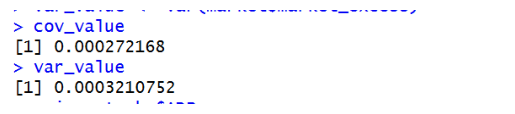

In [9]:
# R Code for Car and Var continues from Part A code
stock3_excess <- stocks$ADP - market$rf_monthly

cov_value <- cov(stock3_excess, market$market_excess)
var_value <- var(market$market_excess)

cov_value
var_value

img = Image.open(r"C:\Users\gorgi\Downloads\seoul4803\pic41.png")
plt.imshow(img)
plt.axis("off")
plt.show()

# Part C

An AI summarized stock #3 as follows. Two things are wrong. Find both.
“β = 1.18 with t-statistic 0.4, so beta is statistically significant and the stock
is risky. The intercept α = 0.002 with a large t-statistic, so CAPM holds for
this stock.”

Answer: 

1st error: Beta is significant when the t-statistic is 0.4 according to AI. A t-statistic is not significant when |t| < 2. Since |0.4| < 2, beta is not statistically significant. The AI interpreted the meaning backwards. Even though β = 1.18, the beta value alone does not prove significance; the t-statistic is what tells us whether beta is significantly different from 0.

2nd error: The AI says CAPM holds because alpha has a large t-statistic. This is wrong because a large t-statistic on alpha means alpha is significantly different from 0. If alpha ≠ 0, then CAPM is rejected, not confirmed. CAPM holds when alpha is not significantly different from 0, so the AI’s logic is backwards.

# Part D

- Beta is about 0.8477. Since β < 1, stock #3 is defensive, meaning it moves less than the market on average. For example, if the market excess return changes by 1%, stock #3’s excess return is expected to change by about 0.85%.

- If CAPM is rejected for a stock, that means α is significantly different from 0. Economically, this means the stock earns abnormal return that the market factor does not explain. The stock’s return is not fully explained by market risk alone.

- For the CAPM regression assumption, I would be most worried about whether the errors behave randomly with constant variance for monthly equity returns. I would check this by looking at the residual plots to see if there is a clear pattern or changing spread.